# Evolutionary Simulation Analysis

This notebook presents a complete workflow for analyzing how different testing and intervention policies shape epidemic outcomes, and how the resulting transmission dynamics relate to the viral evolutionary patterns generated in the simulation.

The goal is to connect **policy performance**, **true transmission structure**, and **sequence‑based phylogenetic signals**.

## Overview

We run multiple evolutionary simulations under several policy settings and evaluate:

1. **How quickly diagnosis‑based triggers detect true transmission signals**  
2. **How strongly each intervention reduces total infections**  
3. **How testing and sequencing volumes differ across policies**  
4. **How the infection log’s transmission tree compares to the mutation‑based evolutionary tree**

## 1) Policy Evaluation

We test multiple combinations of:

- testing intensity  
- intervention strength  
- trigger rules  
- random seeds  

For each simulation, we compute:

- detection delay  
- total infections  
- total diagnoses  
- total sequences  
- timing of interventions  

## 2) Detailed Outbreak Timeline

For each policy, we visualize:

- daily and cumulative infections  
- diagnoses and sequences  
- ground‑truth triggers (based on true infections)  
- diagnosis triggers (based on observed diagnoses)  
- intervention start times  
- detection day  

## 3) Transmission Tree Reconstruction

Using the infection log, we reconstruct the **true transmission tree**, where each node represents an infection event (`agentID_day`).  
Sequenced individuals are highlighted to show sampling coverage.

This tree reflects the actual “who‑infected‑whom” structure of the outbreak and provides a baseline for comparing against sequence‑based trees.


In [1]:
import yaml
import os
import sys
import json
import numpy as np
import covasim as cv
import matplotlib.pyplot as plt

Covasim 3.1.8 (2026-05-29) — © 2020-2026 by IDM


In [11]:
print("PWD =", os.getcwd())

sys.path.append("../intervention_search")

from policies.policy_generator import PolicyGenerator
from simulation.runner import run_evo_simulation
from analysis.detection_delay import summarize_detection
from analysis.intervention_timing import summarize_intervention
from analysis.outbreak_impact import summarize_outbreak
from analysis.mutation_tree import build_mutation_tree
from plotting.plot_mutation_tree import plot_mutation_tree, plot_erase_mutation_tree

PWD = /home/jhkim/covasim_project/jhk_covasim4wastewater/weekly_reports


In [3]:
RAW_DIR = "../intervention_search/results/raw"
PROC_DIR = "../intervention_search/results/processed"
FIG_DIR = "../intervention_search/results/figures"

os.makedirs(RAW_DIR, exist_ok=True)
os.makedirs(PROC_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

In [4]:
with open("../intervention_search/configs/sim_pars.yaml") as f:
    sim_pars = yaml.safe_load(f)

with open("../intervention_search/configs/evo_pars.yaml") as f:
    evo_pars = yaml.safe_load(f)

with open("../intervention_search/configs/policy_sets.yaml") as f:
    policy_sets = yaml.safe_load(f)["policy_sets"]

with open("../intervention_search/configs/intervention_policies.yaml") as f:
    intervention_policies = yaml.safe_load(f)["intervention_policies"]

In [5]:
policy_dict = {
    "baseline": intervention_policies["baseline"],
    "policy_A": intervention_policies["policy_A"],
    "policy_B": intervention_policies["policy_B"],
    "policy_C": intervention_policies["policy_C"],
}

## Policy Overview

All policies share the same trigger mechanism:  
a **diagnosis‑based weekly growth trigger** that activates an intervention when observed cases increase rapidly.  
However, once the trigger fires, **each policy applies a different intervention**, with distinct levels of testing, sequencing, and transmission reduction globally.

### **Baseline**
- No intervention is applied even if the trigger condition is met.
- Moderate testing and sequencing. (p_test=0.35, p_seq=0.25)
- Serves as the reference scenario for comparison.

### **Policy A: High Testing, Weak Distancing**
- Higher testing and sequencing rates. (p_test=0.50, p_seq=0.30)
- Only a mild reduction in transmission during intervention. (10%)
- Short intervention duration.
- Represents an early detection through testing, but weak suppression strategy.

### **Policy B: Low Testing, Strong Distancing**
- Lower testing and sequencing. (p_test=0.25, p_seq=0.10)
- Strong reduction in transmission once intervention starts. (40%)
- Includes a quiet period to prevent repeated triggering.
- Represents a late detection due to low testing, but strong suppression once activated strategy.

### **Policy C: Balanced Testing and Distancing**
- Testing and sequencing at moderate levels. (p_test=0.35, p_seq=0.25)
- Moderate reduction in transmission. (25%)
- Short quiet period and short intervention duration.
- Represents a balanced middle‑ground strategy between A and B.

### **Summary**
Although all policies use the **same trigger rule**,  
they differ substantially in:

- **Testing intensity (p_test, p_seq)**  
- **Strength of distancing (beta reduction)**  
- **Intervention duration**  
- **Quiet period behavior**

These differences allow us to evaluate how detection speed and intervention strength jointly influence outbreak outcomes.


In [6]:
N_ENSEMBLE = 3
results_by_policy = {name: [] for name in policy_dict.keys()}

for pname, policy in policy_dict.items():
    print(f"Running ensemble for {pname}...")
    for seed in range(N_ENSEMBLE):
        sim, obs, interv, variant_metrics, results = run_evo_simulation(
            sim_pars=sim_pars,
            evo_pars=evo_pars["evo_pars"],
            policy=policy,
            rand_seed=seed,
        )

        det = summarize_detection(sim, obs)          # returns: first_detection_day, detection_delay, detection_success_window
        intv = summarize_intervention(obs, interv)   # returns: detection_day, first_intervention_day, intervention_delay, intervention_success
        impact = summarize_outbreak(sim, interv)     # returns: total_infections, peak_infections, ...

        total_diag = int(np.sum(obs.daily_diagnoses))
        total_seq = int(np.sum(obs.daily_sequences))

        result = {
            "policy": pname,
            "seed": seed,
            # detection
            "detection_day": det["first_detection_day"],
            "detection_delay": det["detection_delay"],
            # intervention
            "intervention_day": intv["first_intervention_day"],
            "intervention_delay": intv["intervention_delay"],
            # outbreak impact
            "total_infections": impact["total_infections"],
            "peak_infections": impact["peak_infections"],
            # totals
            "total_diagnoses": total_diag,
            "total_sequences": total_seq,
            "results": results,
        }

        results_by_policy[pname].append(result)

print("All ensembles complete.")


Running ensemble for baseline...
Running ensemble for policy_A...
Running ensemble for policy_B...
Running ensemble for policy_C...
All ensembles complete.


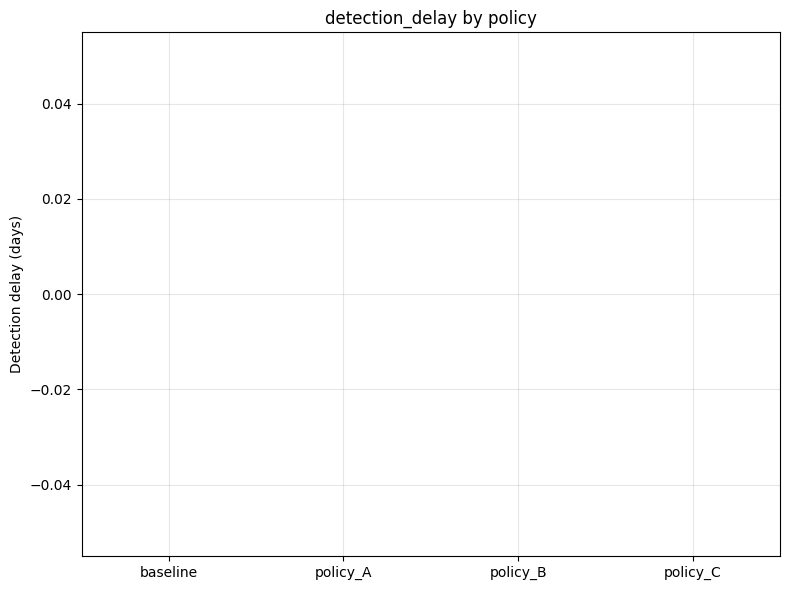

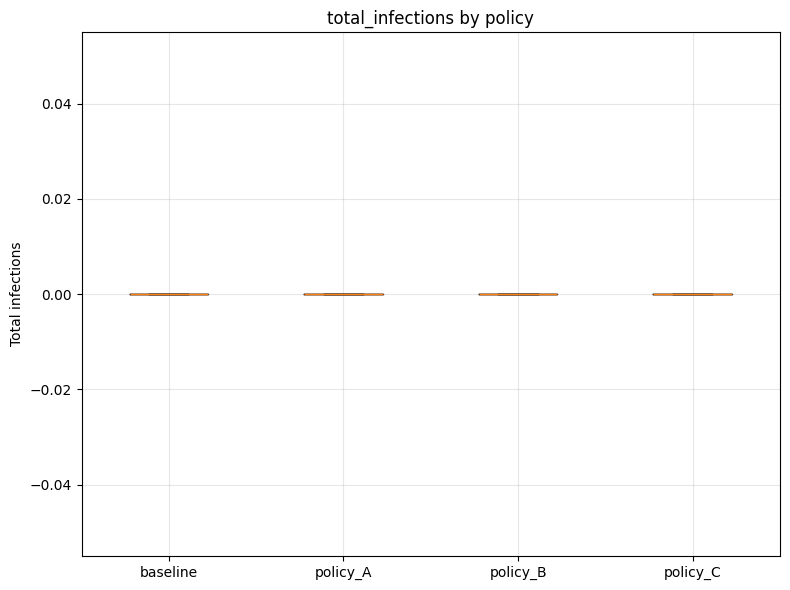

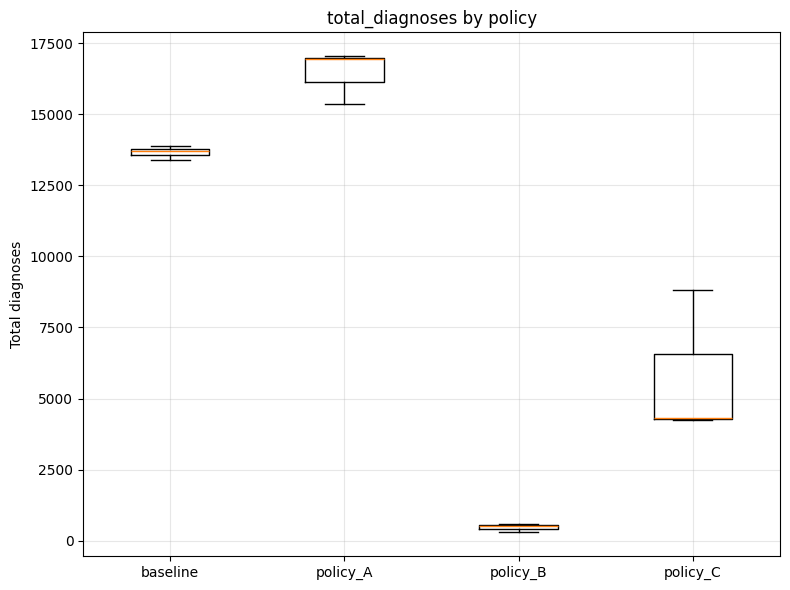

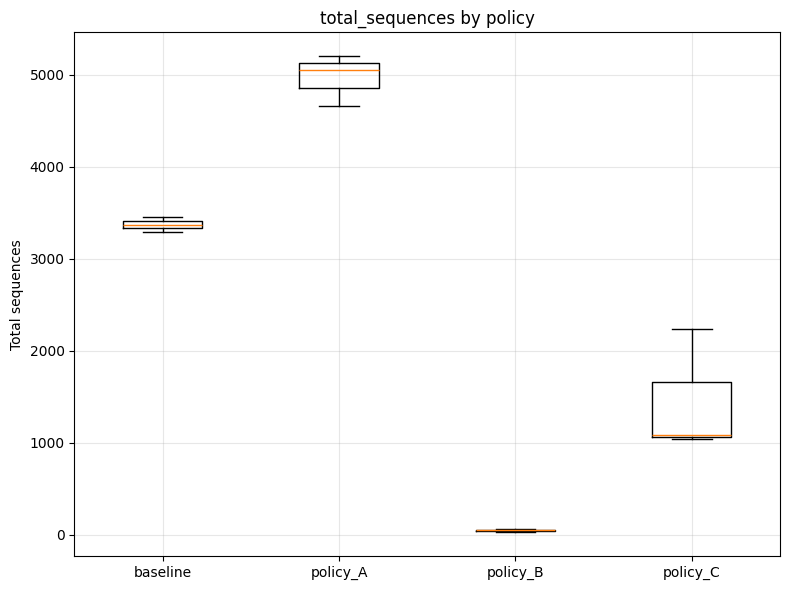

In [7]:
policy_names = ["baseline", "policy_A", "policy_B", "policy_C"]

def grouped_boxplot(metric_key, ylabel, filename):
    data = []
    labels = []
    for pname in policy_names:
        vals = [r[metric_key] for r in results_by_policy[pname] if r[metric_key] is not None]
        data.append(vals)
        labels.append(pname)

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.boxplot(data, tick_labels=labels)  # UPDATED
    ax.set_ylabel(ylabel)
    ax.set_title(f"{metric_key} by policy")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, filename), dpi=200)
    plt.show()
    plt.close(fig)

# 1) detection_delay
grouped_boxplot("detection_delay", "Detection delay (days)", "box_detection_delay.png")
# 2) total_infections
grouped_boxplot("total_infections", "Total infections", "box_total_infections.png")
# 3) total_diagnoses
grouped_boxplot("total_diagnoses", "Total diagnoses", "box_total_diagnoses.png")
# 4) total_sequences
grouped_boxplot("total_sequences", "Total sequences", "box_total_sequences.png")

In [8]:
def plot_detailed_policy_run(pname):
    r = sorted(results_by_policy[pname], key=lambda x: x["seed"])[0]
    seed = r["seed"]
    sim, obs, interv, _, results  = run_evo_simulation(
        sim_pars=sim_pars,
        evo_pars=evo_pars["evo_pars"],
        policy=policy_dict[pname],
        rand_seed=seed,
    )

    T = sim.npts
    days = np.arange(T)

    new_inf = sim.results["new_infections"]
    diag = obs.daily_diagnoses
    seqs = obs.daily_sequences

    cum_inf = np.cumsum(new_inf)
    cum_diag = np.cumsum(diag)
    cum_seqs = np.cumsum(seqs)

    # triggers
    gt_triggers = getattr(interv, "gt_triggers", []) 
    diag_triggers = getattr(interv, "diag_triggers", [])

    # intervention timeline
    intervention_days = getattr(interv, "intervention_days", [])
    intervention_end_days = []

    detection_day = r.get("detection_day", None)

    fig, ax = plt.subplots(figsize=(12, 7))

    # daily curves
    ax.plot(days, new_inf, label="New infections", color="tab:blue", alpha=0.6)
    ax.plot(days, diag, label="Diagnoses", color="tab:orange", alpha=0.6)
    ax.plot(days, seqs, label="Sequences", color="tab:green", alpha=0.6)

    # cumulative curves (solid lines)
    ax.plot(days, cum_inf, label="Cum infections", color="tab:blue", linestyle="-")
    ax.plot(days, cum_diag, label="Cum diagnoses", color="tab:orange", linestyle="-")
    ax.plot(days, cum_seqs, label="Cum sequences", color="tab:green", linestyle="-")

    ax2 = ax.twinx()

    # beta_series = [sim.pars["beta"] for _ in range(sim.npts)]

    # ax2.plot(days, beta_series, label="Beta", color="black", linestyle="--", linewidth=1.5)

    # ax2.set_ylabel("Beta", color="black")
    # ax2.tick_params(axis='y', labelcolor='black')

    # GT triggers → dot on cumulative diagnoses
    if len(gt_triggers) > 0:
        ax.scatter(gt_triggers,
                   cum_diag[gt_triggers],
                   color="red", s=5, label="GT triggers")

    # D triggers → dot on cumulative diagnoses
    if len(diag_triggers) > 0:
        ax.scatter(diag_triggers,
                   cum_diag[diag_triggers],
                   color="blue", s=5, label="D triggers")

    # detection day → solid line
    if detection_day is not None:
        ax.axvline(detection_day, color="red", linestyle="-",
                   linewidth=1.5, label=f"Detection day = {detection_day}")

    # intervention start → solid purple
    for d in intervention_days:
        ax.axvline(d, color="purple", linestyle="-", alpha=0.7)

    # intervention end → solid purple
    for d in intervention_end_days:
        ax.axvline(d, color="purple", linestyle="-", alpha=0.7)

    ax.set_xlabel("Day")
    ax.set_ylabel("Count")
    ax.set_title(f"Detailed timeline for policy: {pname}")

    ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0))
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, f"detailed_{pname}.png"), dpi=200)
    plt.show()
    plt.close(fig)


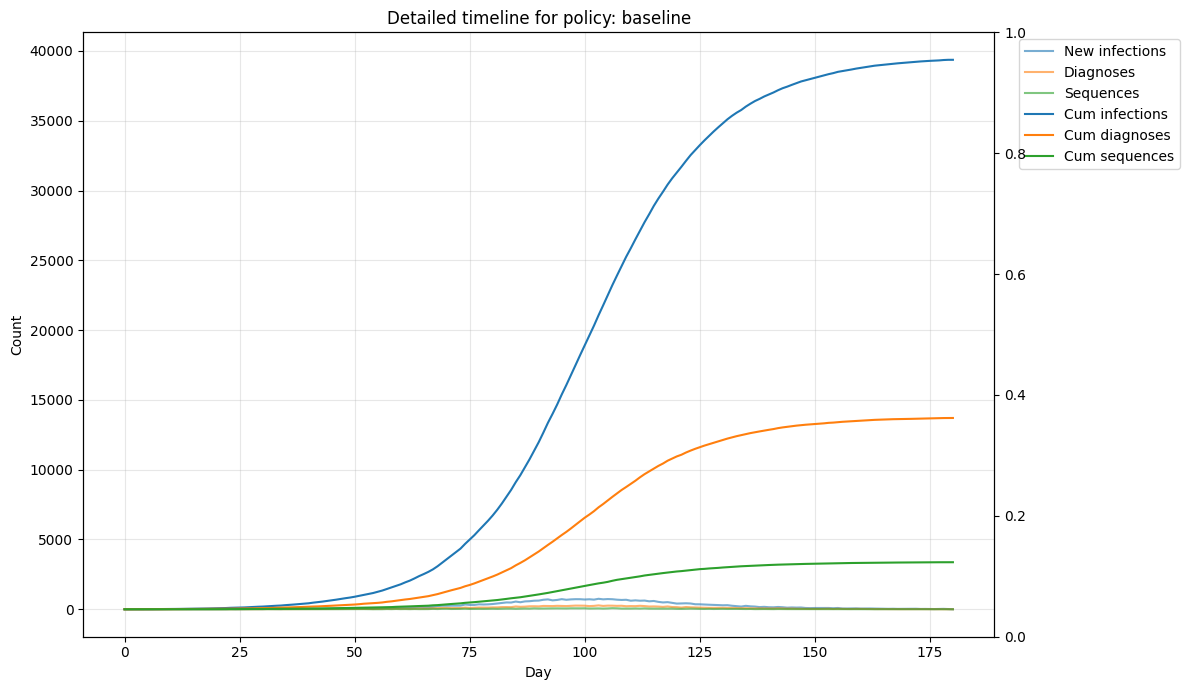

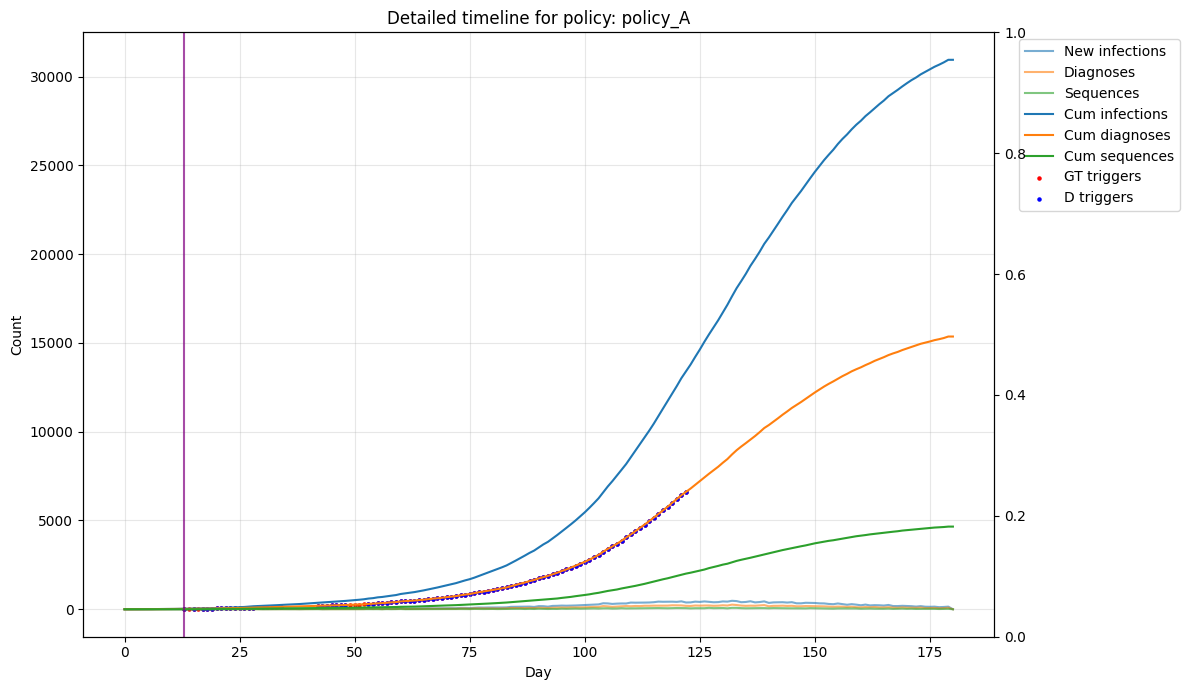

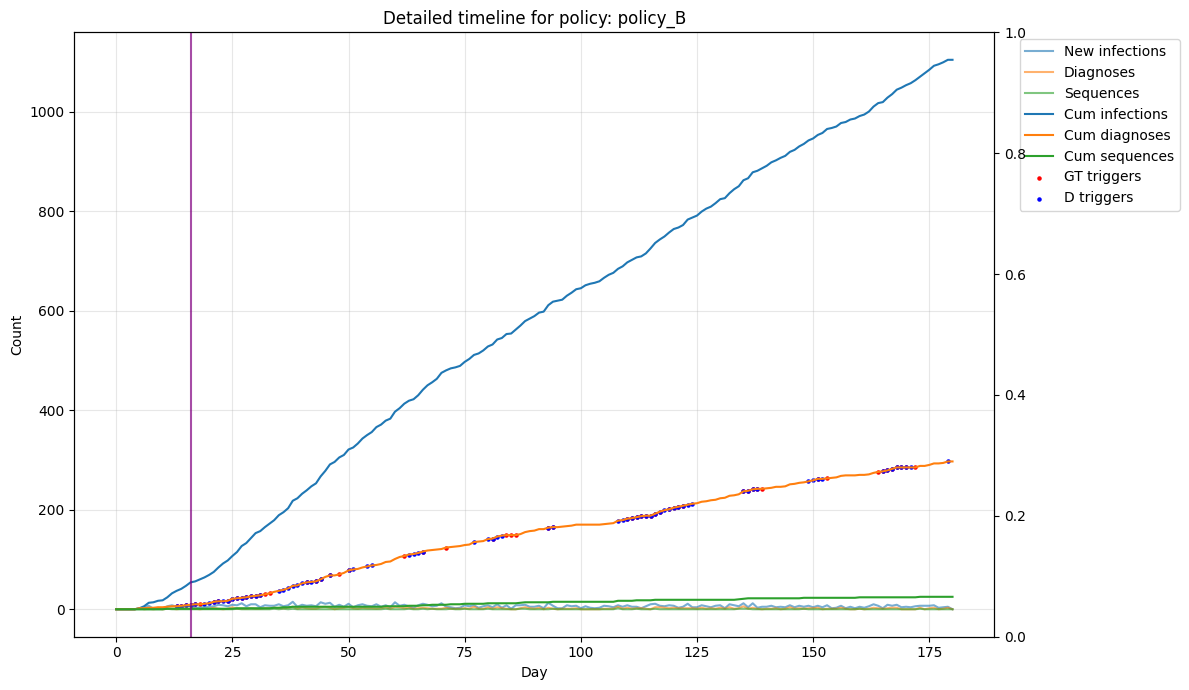

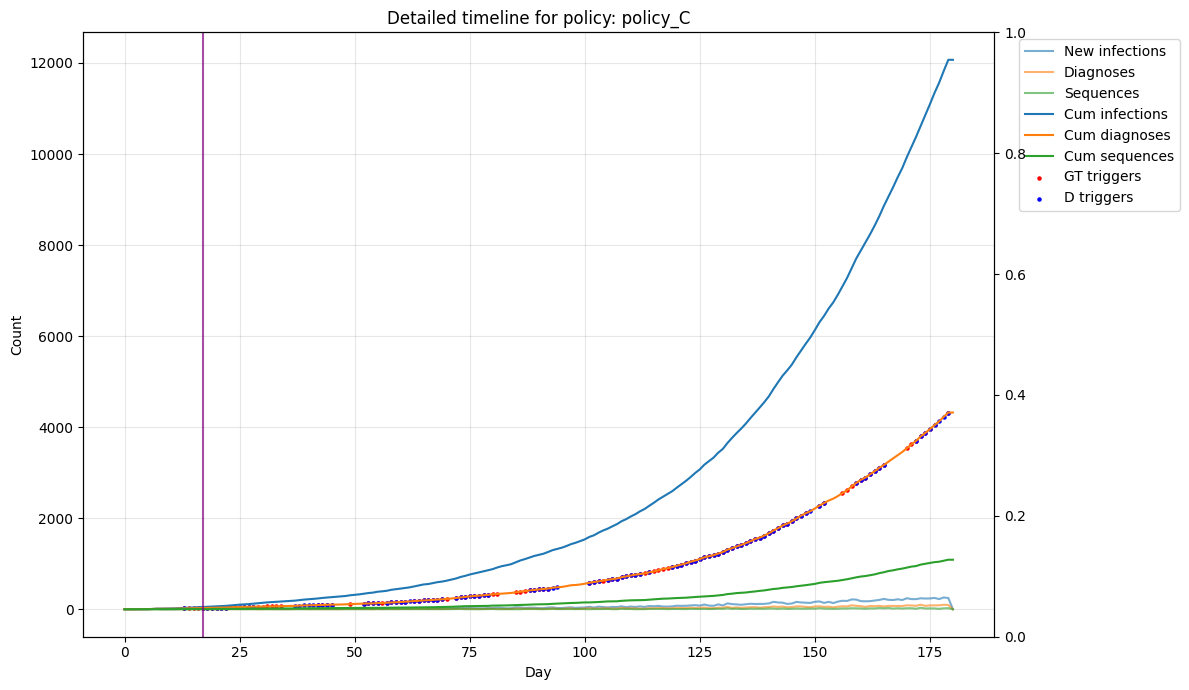

In [9]:
for pname in policy_names:
    plot_detailed_policy_run(pname)

Across all simulations, the strongest distancing combined with low testing produced the lowest total infections. The next best outcome came from the balanced policy with moderate distancing and moderate testing. The least effective was the high‑testing but weak‑distancing policy, where early detection did not compensate for insufficient suppression.

Policy B mutation tree: nodes=1145, edges=1144


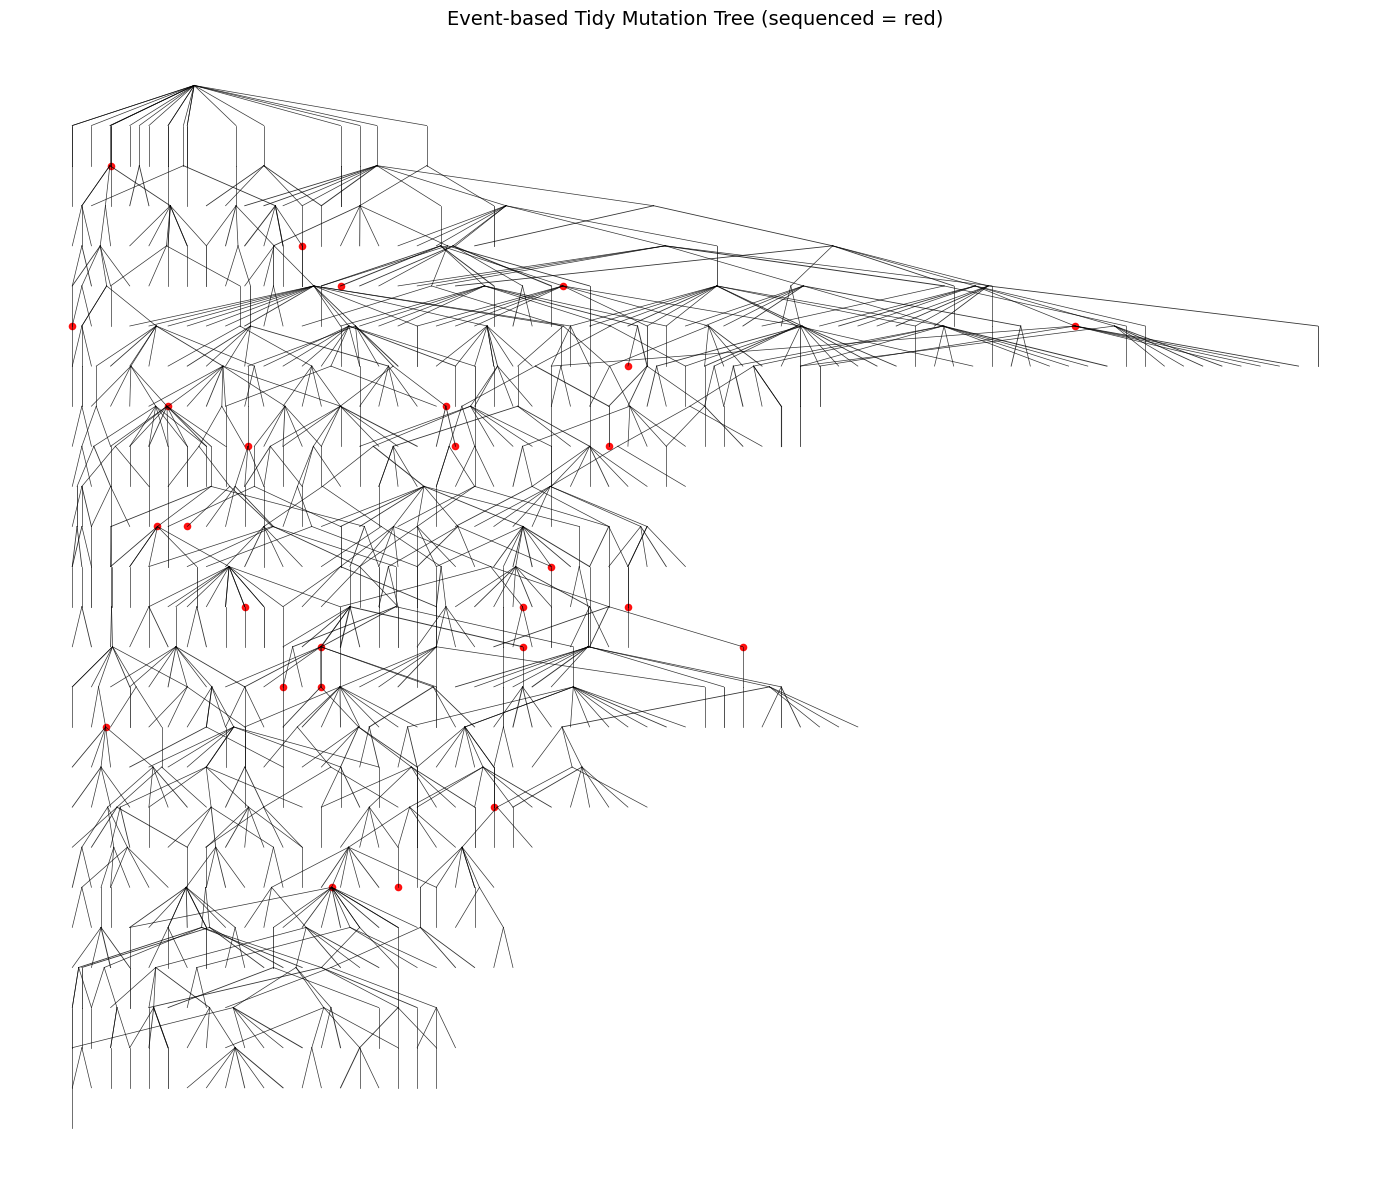

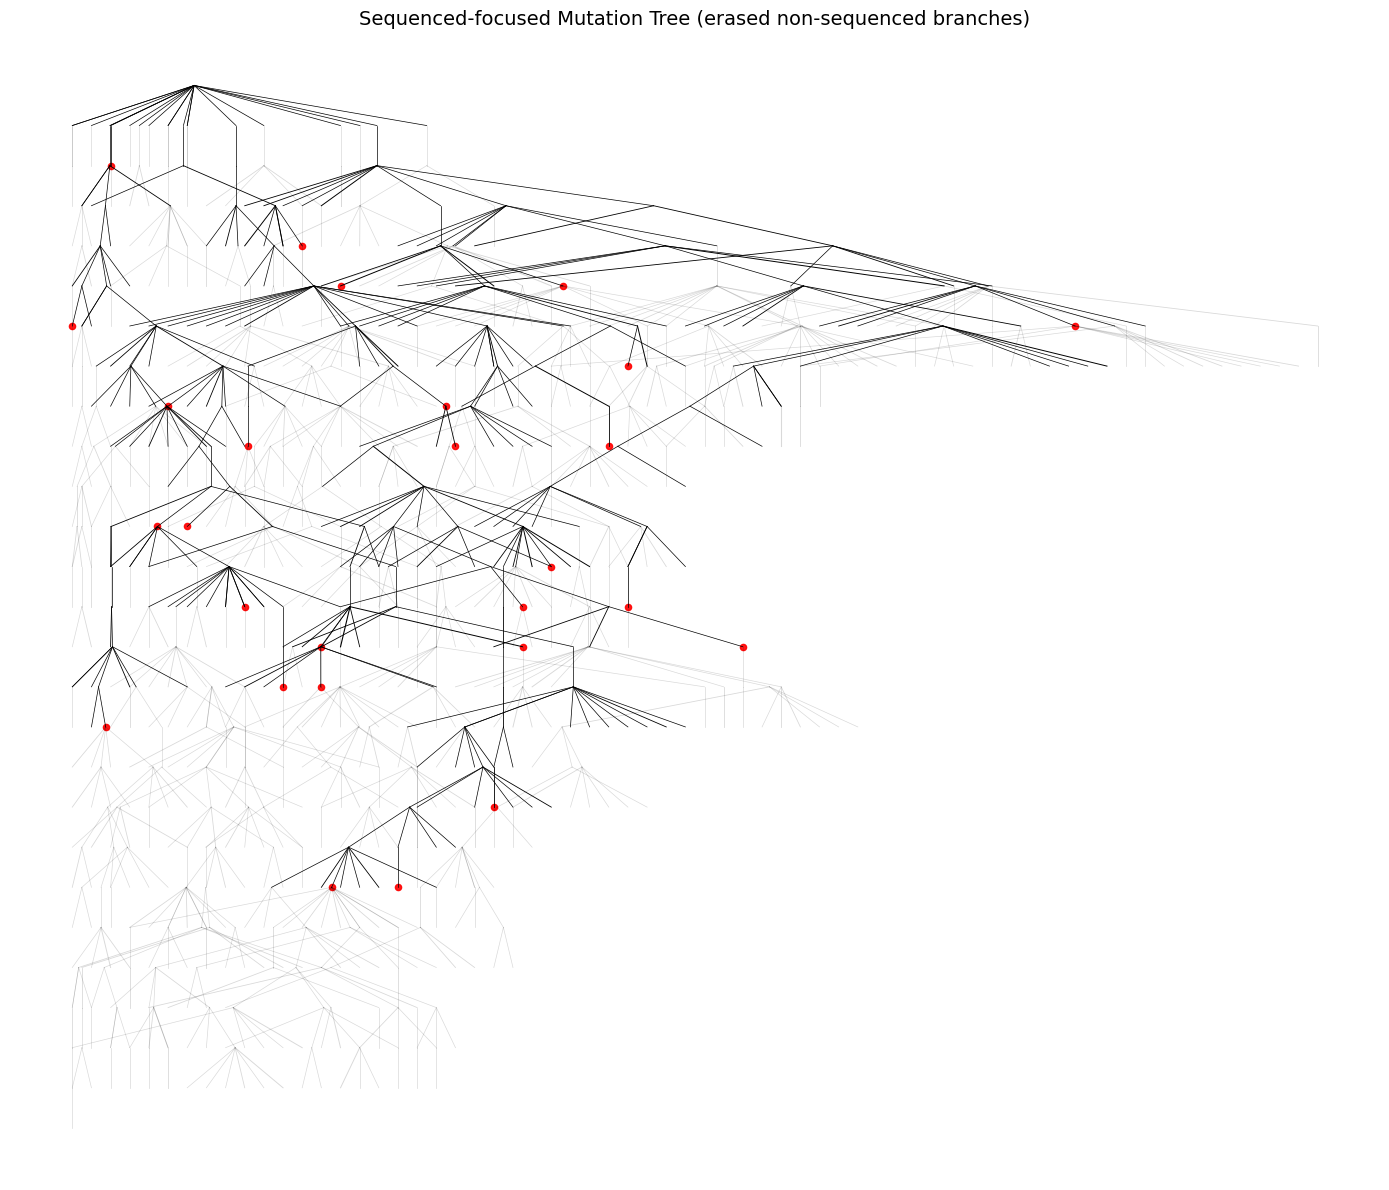

In [ ]:
policy_name = "policy_B"
policy_run = sorted(results_by_policy[policy_name], key=lambda x: x["seed"])[0]
seedB = policy_run["seed"]

simB, obsB, intervB, _, results = run_evo_simulation(
    sim_pars=sim_pars,
    evo_pars=evo_pars["evo_pars"],
    policy=policy_dict[policy_name],
    rand_seed=seedB,
)

sequenced_agents = set()
for day_list in obsB.daily_sequenced_agents:
    sequenced_agents.update(day_list)

G = build_mutation_tree(simB, sequenced_agents=sequenced_agents)
print(f"Policy B mutation tree: nodes={len(G.nodes)}, edges={len(G.edges)}")

plot_mutation_tree(
    G,
    savepath=os.path.join(FIG_DIR, "mutation_tree_policyB_full.png"),
    detection_day=policy_run["detection_day"],
    sequenced_only=False,
    collapse=False,
)
